In [1]:
%pip install --quiet seaborn

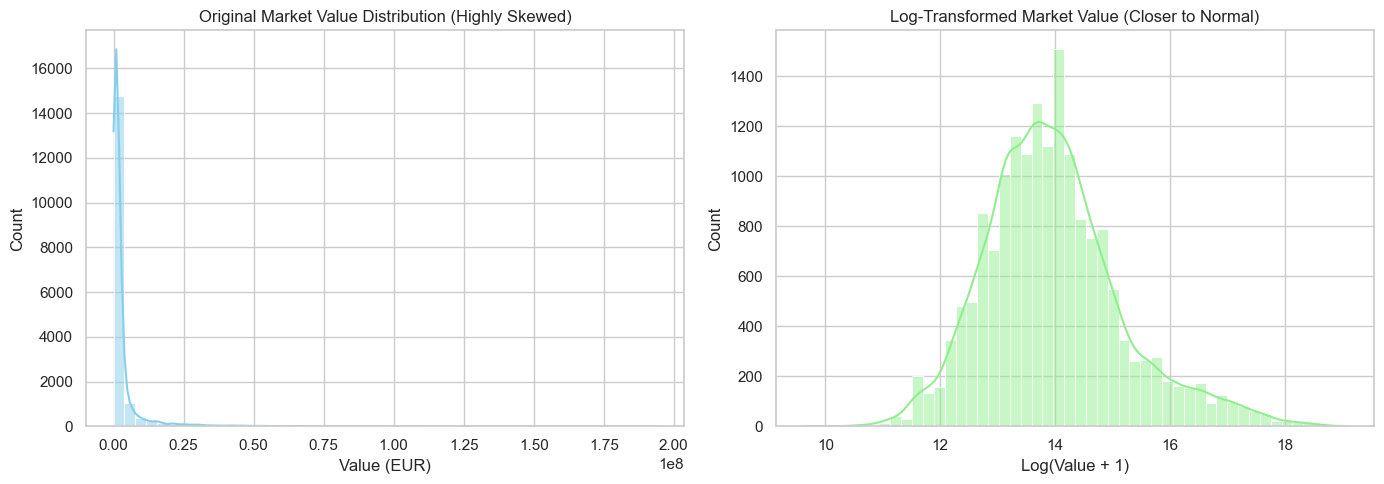

Filtered dataset shape: (17081, 196)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_parquet('data/processed/players_tidy.parquet')

# 2. Filter Data
# According to SDS requirements, we select data from the latest season (22).
# It is strongly recommended to filter out goalkeepers (GK), as their evaluation metrics (e.g., saves) differ significantly from other players, and mixing them in predictions can interfere with the model.
# Additionally, we need to exclude players with NaN or 0 market values (if any).
df_latest = df[(df['season'] == 22) & (df['main_position'] != 'GK') & (df['value_eur'] > 0)].copy()

# 3. Log Transformation of the Target Variable
df_latest['log_value_eur'] = np.log1p(df_latest['value_eur'])

# 4. Visualize Distribution Comparison (To Check Transformation Effect)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_latest['value_eur'], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Original Market Value Distribution (Highly Skewed)')
axes[0].set_xlabel('Value (EUR)')

sns.histplot(df_latest['log_value_eur'], bins=50, ax=axes[1], color='lightgreen', kde=True)
axes[1].set_title('Log-Transformed Market Value (Closer to Normal)')
axes[1].set_xlabel('Log(Value + 1)')

plt.tight_layout()
plt.show()

print(f"Filtered dataset shape: {df_latest.shape}")

In [3]:
%pip install scikit-learn

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# 1. Construct Feature Matrix (X) and Target Variable (y)
# Select the core numerical features we currently have
features = ['overall', 'potential', 'age', 'pace', 'shooting', 
            'passing', 'dribbling', 'defending', 'physic']

X = df_latest[features]
y = df_latest['log_value_eur']

# 2. Split into Training and Test Sets
# 80% for training, 20% for testing, and strictly follow SDS requirements by fixing RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Feature Standardization (Standardization)
# Regularization models (e.g., Ridge) are sensitive to the scale of features, so we need to perform Z-score standardization first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Ridge Regularized Linear Regression Model
# alpha is the regularization strength, which can effectively prevent multicollinearity between features (e.g., overall and passing are highly correlated)
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# 5. Model Prediction and Evaluation
y_pred = ridge_model.predict(X_test_scaled)

# Calculate R^2 Score
r2 = r2_score(y_test, y_pred)

# Calculate MAE (for intuitive understanding, we convert the log-predicted values back to actual EUR amounts to compute the error)
# np.expm1 is equivalent to exp(x) - 1 and is the inverse operation of log1p
y_test_eur = np.expm1(y_test)
y_pred_eur = np.expm1(y_pred)
mae_eur = mean_absolute_error(y_test_eur, y_pred_eur)

print("===== Model Evaluation Report =====")
print(f"Test Set R^2 Score: {r2:.3f}")
print(f"Test Set MAE (Mean Absolute Error): € {mae_eur:,.0f}")

===== Model Evaluation Report =====
Test Set R^2 Score: 0.971
Test Set MAE (Mean Absolute Error): € 654,442


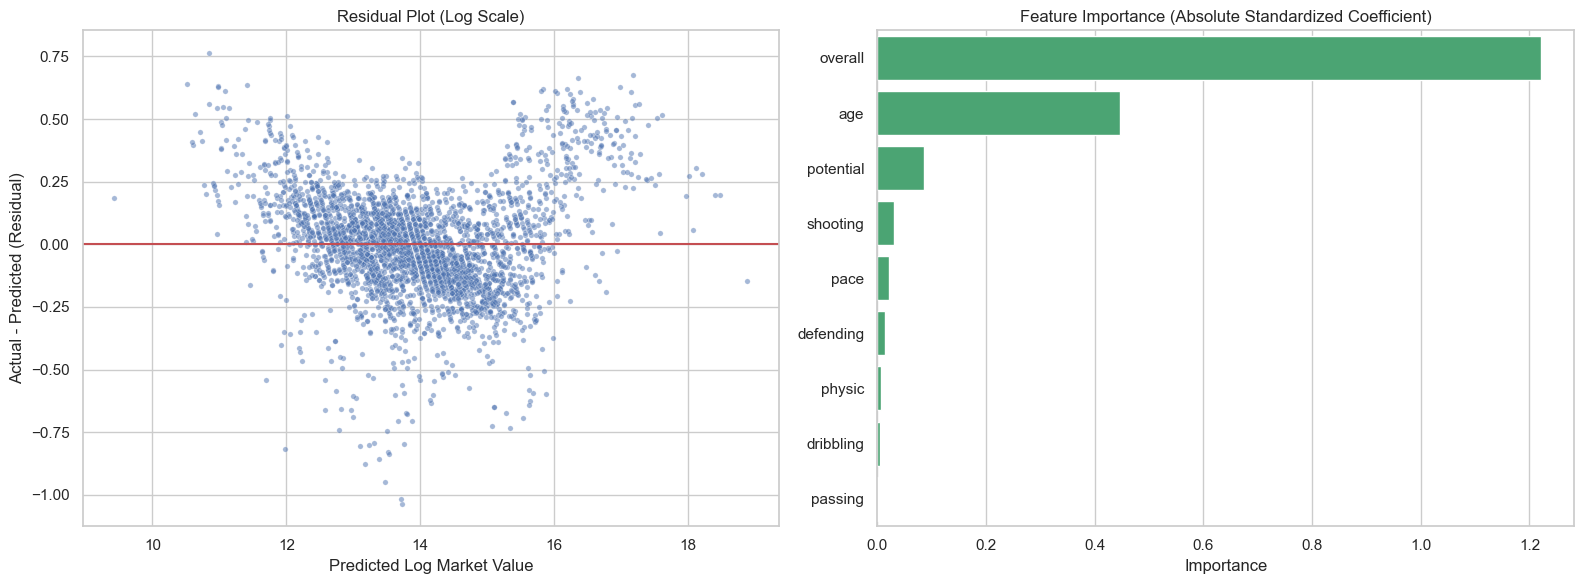

Visualization preview generated!
Simulated JSON output structure for FastAPI interface:
{'r2_score': 0.971, 'mae_eur': 654442.0, 'feature_importance': [{'feature': 'overall', 'importance': 1.2210322272211263}, {'feature': 'age', 'importance': 0.446880078648627}, {'feature': 'potential', 'importance': 0.0849059943258826}, {'feature': 'shooting', 'importance': 0.029943633883957845}, {'feature': 'pace', 'importance': 0.02145186997601762}, {'feature': 'defending', 'importance': 0.01474451841777792}, {'feature': 'physic', 'importance': 0.006919102981391212}, {'feature': 'dribbling', 'importance': 0.005370814162235549}, {'feature': 'passing', 'importance': 0.0004059646902204834}], 'residuals_sample': [{'predicted_log_value': 13.573230904330758, 'residual': 0.07976190060563759}, {'predicted_log_value': 13.37349406060179, 'residual': -0.15581868521297082}, {'predicted_log_value': 16.27937326367754, 'residual': 0.580659779629201}, {'predicted_log_value': 12.64947127810207, 'residual': 0.1852126

In [5]:
# 1. Generate Feature Importance Data
# Ridge model coefficients, taking absolute values to indicate importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': np.abs(ridge_model.coef_)
}).sort_values('importance', ascending=False)

# 2. Generate Residual Data
# Calculate residuals (actual log values - predicted log values)
residuals = y_test - y_pred
residual_data = pd.DataFrame({
    'predicted_log_value': y_pred,
    'residual': residuals
})

# 3. Plot Preview
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Plot: Residual Plot
sns.scatterplot(x='predicted_log_value', y='residual', data=residual_data, alpha=0.5, s=15, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='-')
axes[0].set_title('Residual Plot (Log Scale)')
axes[0].set_xlabel('Predicted Log Market Value')
axes[0].set_ylabel('Actual - Predicted (Residual)')

# Right Plot: Feature Importance
sns.barplot(x='importance', y='feature', data=feature_importance, ax=axes[1], color='mediumseagreen')
axes[1].set_title('Feature Importance (Absolute Standardized Coefficient)')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Simulated JSON Output Structure of FastAPI Interface
response_data = {
    "r2_score": round(r2, 3),
    "mae_eur": round(mae_eur, 0),
    "feature_importance": feature_importance.to_dict(orient='records'),
    # Demo: Extract only the first 5 residual data entries
    "residuals_sample": residual_data.head(5).to_dict(orient='records') 
}

print("Visualization preview generated!")
print("Simulated JSON output structure for FastAPI interface:")
print(response_data)